# Task 2: Sales Prediction System
This notebook contains the complete solution for predicting future product sales based on historical sales data. We introduce advanced feature engineering and an XGBoost model with hyperparameter tuning to achieve a higher R-squared score.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [35]:
import sklearn
import pandas
import joblib

print("scikit-learn==", sklearn.__version__)
print("pandas==", pandas.__version__)
print("joblib==", joblib.__version__)


scikit-learn== 1.6.1
pandas== 2.2.3
joblib== 1.5.3


## 2. Load the Dataset

In [3]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/ML/sales_prediction_task2.csv')

In [4]:
# Convert Date to datetime object
df['Date'] = pd.to_datetime(df['Date'])

In [5]:
# Display the first few rows
df.head()

,Date,ProductID,ProductName,ProductCategory,Price,Promotion,DiscountRate,QuantitySold,Sales,PreviousDaySales,PreviousWeekSales,Rolling7DaySales,Month,DayOfWeek,WeekOfYear,Year
0,2023-01-08,P001,Laptop,Electronics,725.53,Yes,0.242,58,31881.96,27588.63,32713.93,25177.818571,1,6,1,2023
1,2023-01-09,P001,Laptop,Electronics,766.45,No,0.000,26,19927.72,31881.96,18016.36,25058.965714,1,0,2,2023
2,2023-01-10,P001,Laptop,Electronics,762.51,No,0.000,27,20587.74,19927.72,25851.50,25332.017143,1,1,2,2023
3,2023-01-11,P001,Laptop,Electronics,728.33,Yes,0.051,44,30416.18,20587.74,24657.66,24580.051429,1,2,2,2023
4,2023-01-12,P001,Laptop,Electronics,750.82,No,0.000,26,19521.44,30416.18,19575.43,25402.697143,1,3,2,2023


## 3. Data Cleaning, Preprocessing & Feature Engineering

In [6]:
# Check for missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
Date                  0
ProductID             0
ProductName           0
ProductCategory       0
Price                 0
Promotion             0
DiscountRate         43
QuantitySold          0
Sales                 0
PreviousDaySales      0
PreviousWeekSales     0
Rolling7DaySales      0
Month                 0
DayOfWeek             0
WeekOfYear            0
Year                  0
dtype: int64


In [7]:
# Impute missing values for numerical columns with their median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

In [8]:
# Impute missing values for categorical columns with their mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

In [9]:
# --- Advanced Feature Engineering ---
# 1. Calculate Final Price after discount
df['FinalPrice'] = df['Price'] * (1 - df['DiscountRate'])

print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
Date                 0
ProductID            0
ProductName          0
ProductCategory      0
Price                0
Promotion            0
DiscountRate         0
QuantitySold         0
Sales                0
PreviousDaySales     0
PreviousWeekSales    0
Rolling7DaySales     0
Month                0
DayOfWeek            0
WeekOfYear           0
Year                 0
FinalPrice           0
dtype: int64


## 4. Exploratory Data Analysis (EDA)

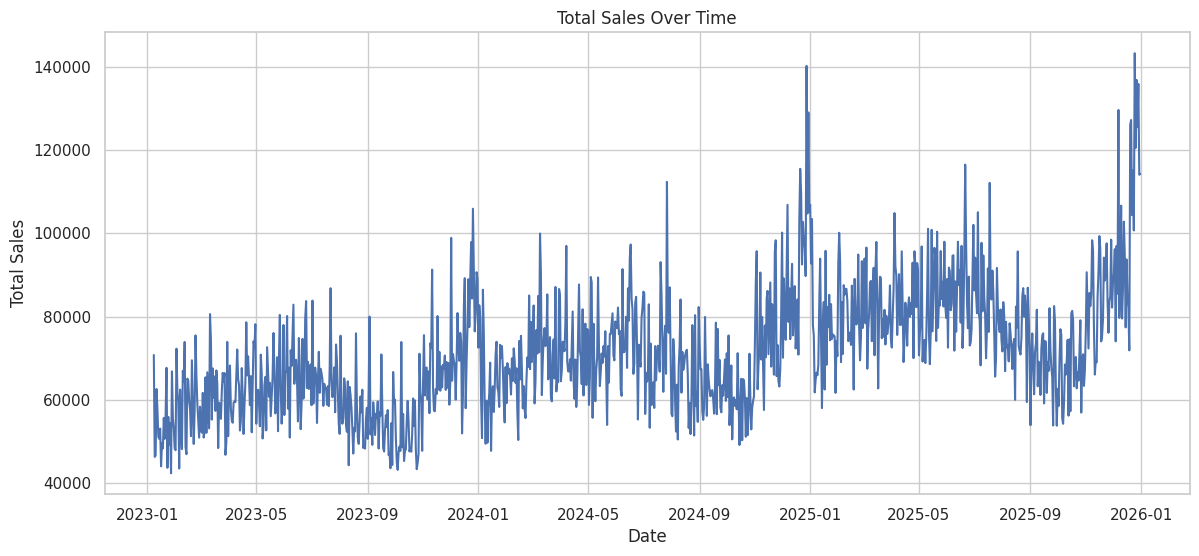

In [10]:
# Set plot style
sns.set_theme(style="whitegrid")

# 1. Plot Sales over Time
plt.figure(figsize=(14, 6))
sales_by_date = df.groupby('Date')['Sales'].sum().reset_index()
sns.lineplot(data=sales_by_date, x='Date', y='Sales')
plt.title('Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

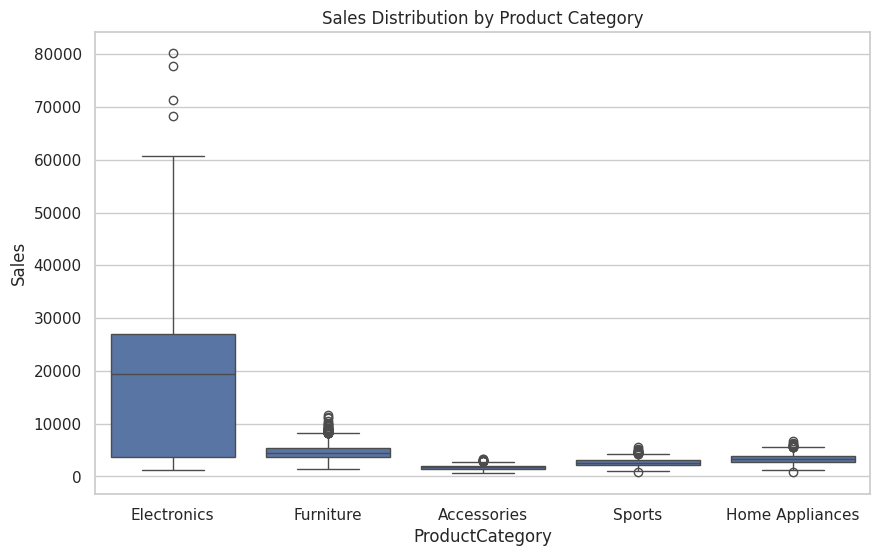

In [11]:
# 2. Sales by Product Category
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='ProductCategory', y='Sales')
plt.title('Sales Distribution by Product Category')
plt.show()

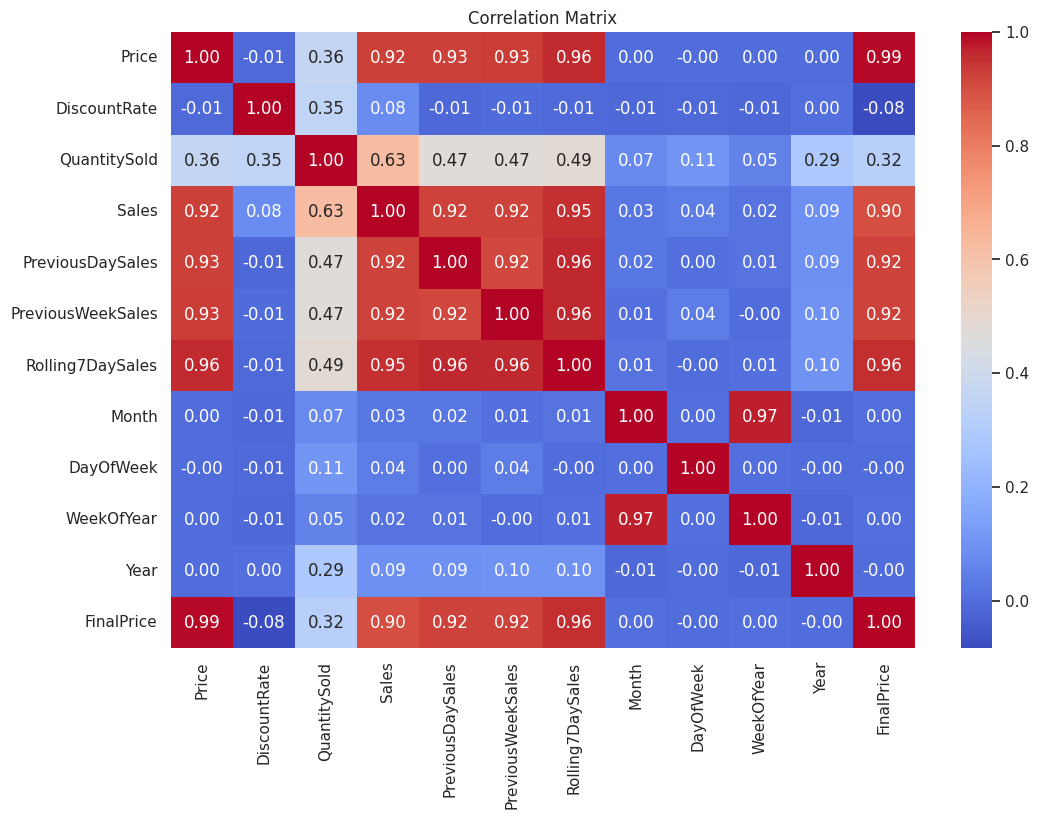

In [12]:
# 3. Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## 5. Prepare Features for Modeling
We select the relevant features including our new `FinalPrice` feature.

In [13]:
# Define Features (X) and Target (y)
features = [
    'ProductCategory', 'Price', 'FinalPrice', 'Promotion', 'DiscountRate', 'QuantitySold',
    'PreviousDaySales', 'PreviousWeekSales', 'Rolling7DaySales',
    'Month', 'DayOfWeek', 'WeekOfYear', 'Year'
]
target = 'Sales'

X = df[features]
y = df[target]

In [14]:
# Identify categorical and numerical columns
categorical_cols = ['ProductCategory', 'Promotion']
numerical_cols = [col for col in features if col not in categorical_cols]

In [15]:
# Create preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

## 6. Build and Train the Model (with XGBoost and Hyperparameter Tuning)


In [16]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

In [17]:
# Transform the features before passing to RandomizedSearchCV
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [18]:
# Define the XGBoost model
xgb_model = xgb.XGBRegressor(random_state=42, objective='reg:squarederror')

In [19]:
# Define the hyperparameter grid
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

In [20]:
# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=15,          # Number of parameter settings that are sampled
    scoring='r2',       # Optimize for R-squared
    cv=3,               # 3-fold cross validation
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [21]:
# Fit the random search model
print("Starting Hyperparameter Tuning... This might take a minute.")
random_search.fit(X_train_transformed, y_train)

print("\nBest Parameters found: ", random_search.best_params_)

# Use the best model
best_xgb_model = random_search.best_estimator_

Starting Hyperparameter Tuning... This might take a minute.
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best Parameters found:  {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


## 7. Evaluate the Model

In [22]:
# Predict on test set
y_pred = best_xgb_model.predict(X_test_transformed)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.4f}")

Mean Absolute Error (MAE): 279.28
Mean Squared Error (MSE): 128803.21
Root Mean Squared Error (RMSE): 358.89
R-squared (R2): 0.8113


## 8. Feature Importance

In [23]:
# Extract the feature importances from the best XGBoost model
importances = best_xgb_model.feature_importances_

In [24]:
# Extract feature names after OneHotEncoding
ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe.get_feature_names_out(categorical_cols)
all_feature_names = np.concatenate([numerical_cols, cat_feature_names])

In [25]:
# Create a DataFrame for visualization
importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

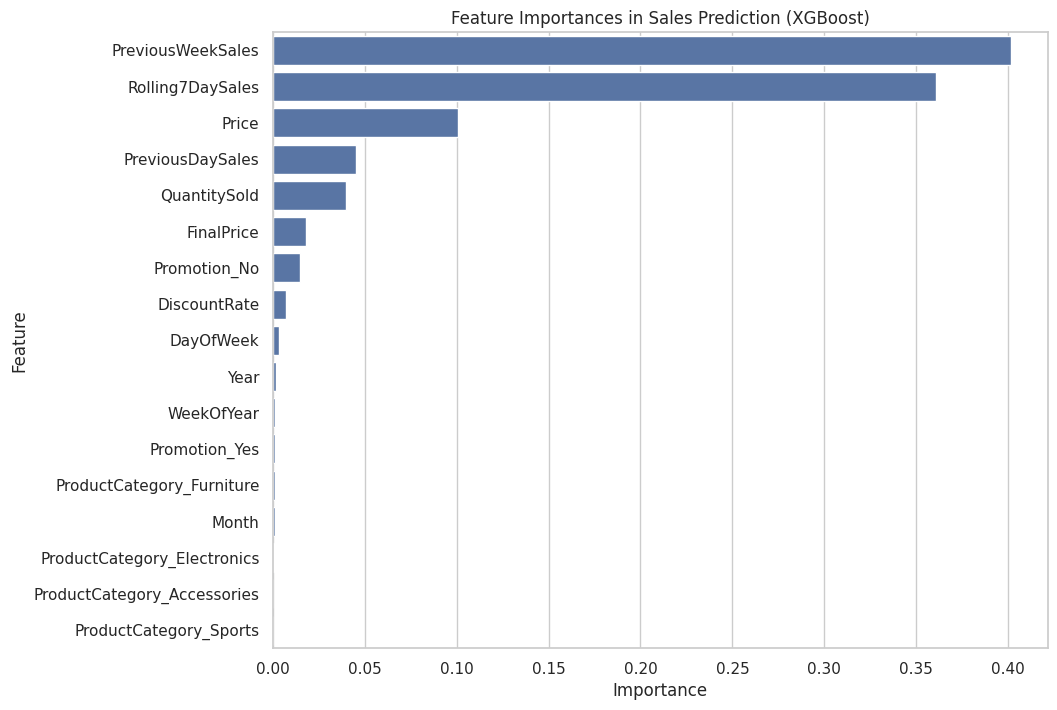

Top 5 most influential features:
             Feature  Importance
5  PreviousWeekSales    0.401464
6   Rolling7DaySales    0.360513
0              Price    0.100840
4   PreviousDaySales    0.045552
3       QuantitySold    0.039862


In [26]:
# Plot Feature Importances
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('Feature Importances in Sales Prediction (XGBoost)')
plt.show()

# Display Top 5 Features
print("Top 5 most influential features:")
print(importance_df.head())

## 9. Prediction Function

In [27]:
def predict_sales_improved(product_category, price, promotion, discount_rate, quantity_sold,
                  prev_day_sales, prev_week_sales, rolling_7_day_sales,
                  month, day_of_week, week_of_year, year):
    """
    Predicts future product sales given historical and product inputs using the optimized model.
    """
    # Calculate derived feature
    final_price = price * (1 - discount_rate)

    # Create a dataframe with the user inputs
    input_data = pd.DataFrame([{
        'ProductCategory': product_category,
        'Price': price,
        'FinalPrice': final_price,
        'Promotion': promotion,
        'DiscountRate': discount_rate,
        'QuantitySold': quantity_sold,
        'PreviousDaySales': prev_day_sales,
        'PreviousWeekSales': prev_week_sales,
        'Rolling7DaySales': rolling_7_day_sales,
        'Month': month,
        'DayOfWeek': day_of_week,
        'WeekOfYear': week_of_year,
        'Year': year
    }])


In [29]:
def predict_sales_improved(product_category, price, promotion, discount_rate, quantity_sold,
                  prev_day_sales, prev_week_sales, rolling_7_day_sales,
                  month, day_of_week, week_of_year, year):
    """
    Predicts future product sales given historical and product inputs using the optimized model.
    """
    # Calculate derived feature
    final_price = price * (1 - discount_rate)

    # Create a dataframe with the user inputs
    input_data = pd.DataFrame([{
        'ProductCategory': product_category,
        'Price': price,
        'FinalPrice': final_price,
        'Promotion': promotion,
        'DiscountRate': discount_rate,
        'QuantitySold': quantity_sold,
        'PreviousDaySales': prev_day_sales,
        'PreviousWeekSales': prev_week_sales,
        'Rolling7DaySales': rolling_7_day_sales,
        'Month': month,
        'DayOfWeek': day_of_week,
        'WeekOfYear': week_of_year,
        'Year': year
    }])

    # Preprocess the input data
    input_transformed = preprocessor.transform(input_data)

    # Predict using the best model
    predicted_sales = best_xgb_model.predict(input_transformed)[0]
    return predicted_sales

In [31]:
# Example Usage:
estimated_sales = predict_sales_improved(
    product_category='Electronics',
    price=750.0,
    promotion='Yes',
    discount_rate=0.15,
    quantity_sold=45,
    prev_day_sales=28000.0,
    prev_week_sales=26000.0,
    rolling_7_day_sales=27000.0,
    month=11,
    day_of_week=4,
    week_of_year=45,
    year=2024
)
print(f"\nEstimated Sales : ${estimated_sales:.2f}")


Estimated Sales : $29564.60


### Save The Model

In [34]:
import joblib

# Save the preprocessor
joblib.dump(preprocessor, '/content/drive/MyDrive/ML/preprocessor.pkl')
print("Preprocessor saved as preprocessor.pkl")

# Save the best XGBoost model
joblib.dump(best_xgb_model, '/content/drive/MyDrive/ML/xgboost_sales_model.pkl')
print("Model saved as xgboost_sales_model.pkl")

Preprocessor saved as preprocessor.pkl
Model saved as xgboost_sales_model.pkl


You can load the saved model and preprocessor at any time using:

```python
# To load the model and preprocessor later
loaded_model = joblib.load(model_path)
loaded_preprocessor = joblib.load(preprocessor_path)

# Now you can use loaded_model and loaded_preprocessor for predictions
# For example, replace 'best_xgb_model' and 'preprocessor' with 'loaded_model' and 'loaded_preprocessor'
# in the predict_sales_improved function if you redefine it after loading.
```